# Regularisation Theory

So far, all the statistical learning models we have discussed focus solely on reducing the error when compared to the training data. This could make the models less generalisable to unseen test data, leading to lower prediction accuracy.

For example, a regression model might try to fit the variations in the training data too closely, capturing random fluctuations in observations instead of the general trend.

Regularisation acts as a balancing constraint to force a model to be simple, thereby decreasing the chances of the model capturing random fluctuations.

## Ridge Regression

In least squares regression, the coefficient estimates $\hat{\beta}, \hat{\beta}_0$ were found to minimise the residual sum of squares
$$\text{RSS} = \sum_{i=1}^{n}(y_i - \beta_0 - x_i^T\beta)^2$$

In this topic, the intercept term is often treated differently from other coefficient estimates, so we do not include the constant predictor in our $X$ vectors. With $p$ non-constant predictor variables $X_1, \dots, X_p$, the observation will be $x = (x_1, \dots, x_p)^T$ and the associated coefficient estimates will be $\beta = (\beta_1, \dots, \beta_p)^T$ with intercept $\beta_0$.

Centering our data will remove the intercept term $\beta_0$. From here onwards, we use centred data.

In ridge regression, the coefficient estimates are found to minimise the penalised residual sum of squares (PRSS), with an extra $L_2$ norm penalty term added:

$$\begin{aligned}
\text{PRSS} &= \sum_{i=1}^{n}(y_i - x_i^T\beta)^2 + \lambda\sum_{j=1}^{n}\beta_j^2
\\&= \lVert\mathbf{y} - \mathbf{X}\beta\rVert^2 + \lambda\lVert\beta\rVert^2
\end{aligned}
$$

Here, $\lambda$ is a tuning parameter to control the tradeoff between minimising deviation of the model from the training data, and simplifying the model. Since the second term $\lambda \lVert\beta\rVert^2$ is small when $\beta$ is close to $0$, it has the effect of shrinking the estimates $\beta_j$ towards $0$, so we call the second term a shrinkage penalty.

To fit a ridge regression model with tuning parameter $\lambda$, we minimise
$$\begin{aligned}
\text{PRSS} &= \lVert\mathbf{y} - \mathbf{X}\beta\rVert^2 + \lambda \lVert\beta\rVert^2 
\\&= \beta^T (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})\beta - \beta^T(\mathbf{X}^T \mathbf{y}) + \mathbf{y}^T\mathbf{y}
\end{aligned}
$$

which is achieved when $\beta = (\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})^{-1}(\mathbf{X}^T \mathbf{y})$. Therefore, the ridge regression coefficient estimate is
$$\hat{\beta}_{\text{ridge}} = (\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y} $$

### Geometrical Interpretation

To get a geometric interpretation of ridge regression, we need to introduce the singular value decomposition of our data matrix $\mathbf{X}$:
$$\mathbf{X} = \mathbf{U}\mathbf{D}\mathbf{V}^T$$
where $\mathbf{U}\in \mathbb{R}^{n\times p}$ while $\mathbf{D}, \mathbf{V}\in \mathbb{R}^{p\times p}$, $\mathbf{D}$ is diagonal, and $\mathbf{U}^T\mathbf{U} = \mathbf{V}^T\mathbf{V} = \mathbf{I}_p$.

Notice that $\mathbf{X}^T\mathbf{X} = \mathbf{V}\mathbf{D}^2\mathbf{V}^T$, so from our discussion of the shape of data when plotted in the $p$-dimensional sample space, we see that 
* $\mathbf{V}$ is a matrix whose columns $\mathbf{v}_i$ are the principal axes of our data, and 
* the diagonal entries of $\mathbf{D}$ are $\sqrt{n}$ times the sample variances along the corresponding principal axes

The columns of $\mathbf{U}$ form an orthonormal basis of the sample space (column space of $\mathbf{X}$).

For any observation $x\in \mathbb{R}^p$, we can decompose it into the principal components $x = \theta_1 \mathbf{v}_1 + \dots + \theta_p \mathbf{v}_p = \mathbf{V}\theta $ by calculating the scores $\theta^T = x^T \mathbf{V}$. We can do this for all $n$ observations in the $\mathbf{X}$ matrix and end up with the $n\times p$ scores matrix $\mathbf{Z}=\mathbf{X}\mathbf{V}$. Substituting the singular value decomposition of $\mathbf{X}$, we get
$$\mathbf{Z} = \mathbf{U}\mathbf{D}\mathbf{V}^T\mathbf{V} = \mathbf{U}\mathbf{D}$$

Therefore, the columns of $\mathbf{U}$ form the normalised score vectors of the observations in $\mathbf{X}$ in each of the $p$ principal components.

In a least squares regression model, the predicted response for some observation $x = \theta_1 \mathbf{v}_1 + \dots + \theta_p \mathbf{v}_p = \mathbf{V}\theta$ is
$$\begin{aligned}
\hat{y} &= x^T(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} \\
&= x^T(\mathbf{V}\mathbf{D}^2\mathbf{V}^T)^{-1}\mathbf{V}\mathbf{D}\mathbf{U}^T\mathbf{y}\\
&= (\mathbf{V}^{-1} x)^T\mathbf{D}^{-1}\mathbf{U}^T\mathbf{y}\\
&= \theta^T \mathbf{D}^{-1} \mathbf{U}^T\mathbf{y}\\
&= \sum_{i=1}^{p} \frac{\theta_i}{d_i} \mathbf{u}_i^T\mathbf{y}
\end{aligned}
$$

In a ridge regression model, however, the predicted response is
$$
\begin{aligned}
\hat{y} &= x^T(\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y} \\
&= x^T(\mathbf{V}(\mathbf{D}^2 + \lambda \mathbf{I})\mathbf{V}^T)^{-1}\mathbf{V}\mathbf{D}\mathbf{U}^T\mathbf{y}\\
&= x^T(\mathbf{V}^{-T}(\mathbf{D}^2 + \lambda\mathbf{I})^{-1})\mathbf{D}\mathbf{U}^T\mathbf{y}\\
&= (\mathbf{V}^{-1}x)^T(\mathbf{D}^2 + \lambda\mathbf{I})^{-1}\mathbf{D}\mathbf{U}^T\mathbf{y}\\
&= \theta^T(\mathbf{D}^2 + \lambda\mathbf{I})^{-1}\mathbf{D}\mathbf{U}^T\mathbf{y}\\
&= \sum_{i=1}^{p} \frac{\theta_i d_i}{d_i^2 + \lambda} \mathbf{u}_i^T\mathbf{y}\\
&= \sum_{i=1}^{p} \frac{d_i^2}{d_i^2 + \lambda} \left(\frac{\theta_i}{d_i}\mathbf{u}_i^T\mathbf{y}\right)
\end{aligned}
$$

As we can see, ridge regression applies a shrinking factor $\frac{d_i^2}{d_i^2 + \lambda}$ to the component of observation $x$ in the direction of the $i$-th principal axis $\mathbf{v}_i$. Furthermore, the smaller the value of $d_i^2$ (i.e. $\sqrt{n}$ times the sample variance along the $i$-th principal axis), the more drastic the shrinking factor. This turns out to be a desirable effect since it reduces the variance of the model's predictions, as we will discuss next.

In a least squares model, the covariance matrix of the least squares coefficient estimate is $(\mathbf{X}^T\mathbf{X})^{-1}\sigma^2$. Using the eigen-decomposition of $\mathbf{X}^T\mathbf{X}$, this becomes $\mathbf{V}\mathbf{D}^{-1}\mathbf{V}^T\sigma^2$. Principal components with small eigenvalues $d_i$ cause the diagonal matrix $\mathbf{D}^{-1}$ to have large diagonal entries $\frac{1}{d_i}$, blowing up the variance of the coefficient estimate. As such, shrinking the principal components with smaller eigenvalues can reduce the prediction variance.

### Connection with Bayesian Inference

In Bayesian inference, we treat the coefficient estimate $\beta$ as a random variable with some prior probability distribution $\pi(\beta)$. To simplify the computations, we assume that the observations of the predictor variables $X$ are fixed (i.e. $\mathbf{X}$ is fixed), and that only the responses $y$ are randomly distributed. We can then use Bayes' Theorem to compute the probability distribution of $\beta$ given our observations of the response variable, $\mathbb{P}(\beta|\mathbf{y})$:

$$\mathbb{P}(\beta|\mathbf{y}) = \frac{\mathbb{P}(\mathbf{y}|\beta)\mathbb{P}(\beta)}{\mathbb{P}(\mathbf{y})}\propto \mathbb{P}(\mathbf{y}|\beta)\mathbb{P}(\beta)$$

Assuming independent and identically distributed Gaussian errors in the responses $y_i$, we have
$$\mathbb{P}(\mathbf{y}|\beta) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\sigma}{\exp\left(-\frac{1}{2\sigma}(y_i - x_i^T\beta)^2\right)}=\frac{1}{(2\pi\sigma^2)^{n/2}}{\exp\left(-\frac{1}{2\sigma}\lVert\mathbf{y}-\mathbf{X}\beta\rVert^2\right)}$$

Ridge regression has a connection with Bayesian inference when the prior distribution $\pi(\beta)$ is chosen to be of the form $\beta \sim \text{N}(\mathbf{0}, \lambda^2\mathbf{I})$. In this case,

$$\pi(\beta) = \prod_{j=1}^{p}\frac{1}{\sqrt{2\pi}\lambda}\exp\left(-\frac{1}{2\lambda}\beta_j^2\right)=\frac{1}{(2\pi\lambda^2)^{p/2}}\exp\left(-\frac{1}{2\lambda}\lVert\beta\rVert^2\right)$$

Then the negative of the log-posterior distribution will be

$$
\begin{aligned}
-\log \mathbb{P}(\beta|\mathbf{y}) 
&= -\log\mathbb{P}(\mathbf{y}|\beta) -\log\pi(\beta)\\
&= \frac{n}{2}\log({2\pi\sigma^2}) + \frac{p}{2}\log({2\pi\lambda^2}) + \frac{1}{2\sigma}\lVert\mathbf{y}-\mathbf{X}\beta\rVert^2 + \frac{1}{2\lambda}\lVert\beta\rVert^2
\end{aligned}
$$

The posterior mode occurs at some value of $\beta$ which minimises $-\log \mathbb{P}(\beta|\mathbf{X})$. Removing the terms independent of $\beta$, and multiplying by $2\sigma$, the relevant expression to minimise will be

$$\lVert\mathbf{y}-\mathbf{X}\beta\rVert^2 + \frac{\sigma}{\lambda}\lVert\beta\rVert^2$$

which closely resembles the penalised residual sum of squares given by ridge regression.

### Implementation of Ridge Regression

To compute the ridge coefficient estimates $\hat{\beta}_\text{ridge}$, we often use the Singular Value Decomposition of $\mathbf{X}$:

$$
\begin{aligned}
\hat{\beta}_\text{ridge} &= (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}\\
&= (\mathbf{V}(\mathbf{D}^2 + \lambda \mathbf{I})\mathbf{V}^T)^{-1}\mathbf{V}\mathbf{D}\mathbf{U}^T\mathbf{y}\\
&= \mathbf{V}(\mathbf{D}^2 + \lambda\mathbf{I})^{-1}\mathbf{D}\mathbf{U}^T\mathbf{y}
\end{aligned}
$$

The code below will implement this and plot the coefficients as $\lambda$ is increased from $0$ to infinity:

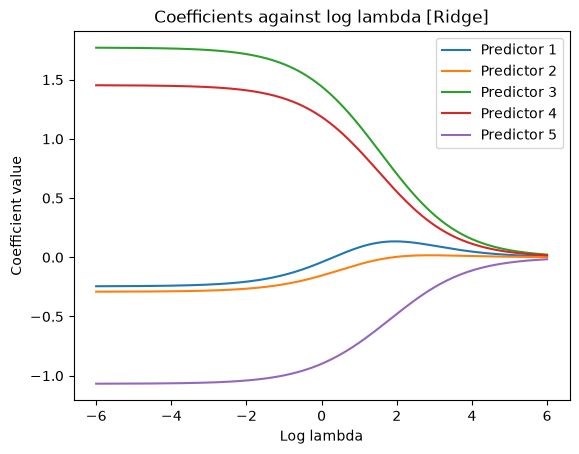

In [234]:
import numpy as np

rng = np.random.default_rng(seed=8)

X = rng.random(size=(50,5))
beta_true = rng.random(size=5)
beta_0_true = rng.random()

y = X @ beta_true + beta_0_true + rng.normal(0, 3, size=50)

means = np.mean(X, axis=0)
X_centred = X - means
y_centred = y - np.mean(y)

U, D, Vt = np.linalg.svd(X_centred, full_matrices=False)

def beta_hat(lambda_param):
    diag_entries = D / (D ** 2 + lambda_param)
    beta_hat = Vt.T @ np.diag(diag_entries) @ U.T @ y_centred
    return beta_hat

log_lambda = np.linspace(-6, 6, 200)
lambda_param = np.exp(log_lambda)
beta_hats = np.array([beta_hat(l) for l in lambda_param])

import matplotlib.pyplot as plt

for i in range(5):
    plt.plot(log_lambda, beta_hats[:,i], label=f'Predictor {i+1}')

plt.xlabel('Log lambda')
plt.ylabel('Coefficient value')
plt.title('Coefficients against log lambda [Ridge]')
plt.legend();

We can also plot the path of coefficients another way - against the L2 norm of the coefficient vector. Doing so, we get the following plot:

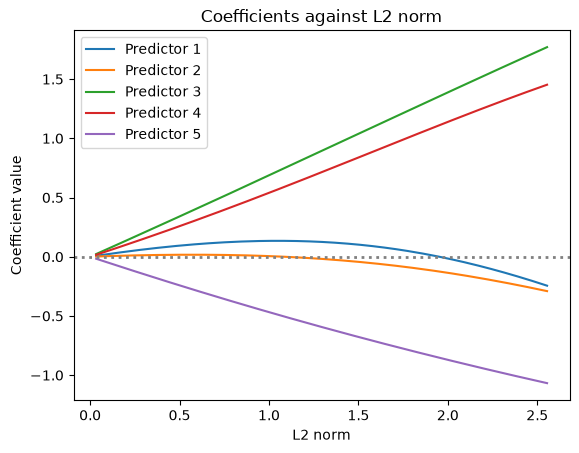

In [235]:
beta_L2 = np.linalg.norm(beta_hats, axis=1)

for i in range(5):
    plt.plot(beta_L2, beta_hats[:,i], label=f'Predictor {i+1}')

plt.axhline(y=0, ls=':', lw=2, color='grey')

plt.title('Coefficients against L2 norm')
plt.xlabel('L2 norm')
plt.ylabel('Coefficient value')
plt.legend();

## Lasso Regularisation

The lasso regularisation adds a penalty to the residual sum of squares in a similar way as in ridge regression. Ridge regression uses the squared $L_2$ norm $\sum_{j=1}^{p}\beta_j^2$ as the penalty term, whereas in the lasso, the $L_1$ norm is used, giving the penalised residual sum of squares

$$\text{PRSS} = \sum_{i=1}^{n} (y_i - \beta_0 - x_i^T\beta )^2 + \lambda\sum_{j=1}^{p}|\beta_j|$$

Using centred data, we once again only consider the coefficients $\beta$ of the $p$ predictor variables, and ignore the intercept term $\beta_0$:

$$\text{PRSS} = \lVert\mathbf{y} - \mathbf{X}\beta\rVert^2 + \lambda\sum_{j=1}^{p}|\beta_j|$$

### Feature-Selection Ability of the Lasso

The ridge penalty results in proportional shrinking along each principal axis. The lasso, however, tends to shrink some coefficient estimates straight to $0$, thereby achieving feature selection. We discuss why this happens in the next paragraph.

For simplicity, let $\lVert\mathbf{y}-\mathbf{X}\beta\rVert^2 = f(\beta)$. Taking partial derivatives of $\text{PRSS}$ with respect to $\beta_j$, the values $\beta_j$ of $\beta$ that minimise the $\text{PRSS}$ must fall into one of three cases:
1. $\beta_j > 0$ and $\frac{\partial f}{\partial \beta_j} = -\lambda$
2. $\beta_j < 0$ and $\frac{\partial f}{\partial \beta_j} = \lambda$
3. $\beta_j = 0$ and $-\lambda < \frac{\partial f}{\partial \beta_j} < \lambda$

As long as $\frac{\partial f}{\partial \beta_j}$ lies in $(-\lambda, \lambda)$ when evaluated at $\beta_j = 0$, then $\beta_j = 0$ to minimise $\text{PRSS}$.

### Connection with Bayesian Inference

We discussed how using a Gaussian prior in Bayesian inference reduces to a ridge regression formulation. In the case of the lasso, this is a Laplace prior distribution (double exponential):

$$\pi(\beta) = \prod_{j=1}^{p} \frac{1}{2b}\exp\left(-\frac{|\beta_j|}{b}\right) = \frac{1}{(2b)^p}\exp\left(-\frac{1}{b}\sum_{j=1}^{p}|\beta_j|\right)$$

The negative log-posterior will be

$$-\log \mathbb{P}(\beta|\mathbf{y}) = \frac{n}{2}\log(2\pi\sigma^2) + p\log(2b) + \frac{1}{2\sigma}\lVert\mathbf{y}-\mathbf{X}\beta\rVert^2 + \frac{1}{b}\sum_{j=1}^{p}|\beta_j| $$

Minimising this negative log-posterior is equivalent to minimising

$$\lVert\mathbf{y}-\mathbf{X}\beta\rVert^2 + \frac{2\sigma}{b}\sum_{j=1}^{p}|\beta_j|$$

which is essentially the PRSS under lasso regularisation.

# Least Angle Regression

Least Angle Regression (LAR) fits a linear regression model using an algorithmic process starting from zero predictor variable coefficients, eventually ending at the least squares solution. Taking coefficient estimates midway through the LAR process allows us to perform feature selection.

LAR is performed on centred and normalised data. From here on the data matrix $\mathbf{X}$ shall contain $p$ column vectors each with mean entry $0$ and a norm of $1$. The vector $\mathbf{y}$ will also be the centred and normalised response vector.

### Geometric Interpretation

In ordinary least squares regression, we solved for the linear combination $\hat{\mathbf{y}} = \mathbf{X}\beta$ of the $p$ predictor variables that fit the observed responses $\mathbf{y}$ the closest. Geometrically, $\hat{\mathbf{y}}$ was the orthogonal projection from $\mathbf{y}$ onto the column space of $\mathbf{X}$ (the subspace spanned by the $p$ vectors corresponding to the observations of the $p$ predictor variables).

The LAR process can be thought of as a path from the origin $\mathbf{0}$ to this orthogonal projection $\hat{\mathbf{y}}_\text{LS}$ which is the least squares solution.

Since the correlation between two centred vectors $\mathbf{a}, \mathbf{b}$ is computed by

$$\frac{\text{cov}(\mathbf{a}, \mathbf{b})}{\sqrt{\text{var}(\mathbf{a})}\sqrt{\text{var}(\mathbf{b})}} = \frac{\mathbf{a}^T\mathbf{b}}{\lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert}=\cos \theta$$

maximising correlation can be thought of as minimising the acute angle between two vectors, if the candidate vectors are all of the same norm.

Any choice of $\hat{\mathbf{y}}$ within the column space of $\mathbf{X}$ is a linear combination of the observations one or more predictor variables ($\mathbf{x}_j$ vectors). At the start of the LAR path from $\mathbf{0}$ to $\hat{\mathbf{y}}_\text{LS}$, we will use just $1$ predictor variable, and slowly expand the set of predictor variables used (also called the active set of variables).

The variable $X_j$ we choose will be the variable that shows the strongest correlation (positive or negative) with the current residual vector, which we will always denote $\mathbf{r}$. At the beginning, $\mathbf{r} = \mathbf{y}$. 

For any active set of variables $A=\{X_{j_1}, \dots, X_{j_k}\}$, the best-fitted response vector as a linear combination of just these variables, is the perpendicular projection of the response $\mathbf{y}$ onto the subspace spanned by the observation vectors $\mathbf{x}_j$ of the variables in $A$. Denoting the matrix formed by only taking the column vectors $\mathbf{x}_j$ for variables $X_j$ in the active set $A$ by $\mathbf{X}_A$, the best-fitted response vector for an active set $A$ is just

$$\hat{\mathbf{y}}_A = \mathbf{X}_A(\mathbf{X}_A^T\mathbf{X}_A)^{-1}\mathbf{X}_A^T \mathbf{y}$$

At the beginning, the best-fitted response vector as a linear combination of just $X_j$, is the perpendicular projection from $\mathbf{y}$ onto $\mathbf{x}_j$, denoted $\hat{\mathbf{y}}_{A_1}$ (we let the current active set be $A_1 = \{X_j\}$). Our LAR path of $\hat{\mathbf{y}}$ will then start from $\mathbf{0}$ and move in a straight line towards $\hat{\mathbf{y}}_{A_1}$, according to

$$\hat{\mathbf{y}}(\alpha) = \mathbf{0} + \alpha \hat{\mathbf{y}}_{A_1} $$

Somewhere along this path, before actually reaching $\hat{\mathbf{y}}_{A_1}$, the LAR algorithm will add in a second variable into the active set to form $A_2 = \{X_{j_1}, X_{j_2}\}$. How this happens is again related to computing correlations. Suppose we stop the path at some $\hat{\mathbf{y}}(\alpha) = \hat{\mathbf{y}}_1$. From this point, the direction towards (not the position of) the best-fitted response vector as a linear combination of variables in any larger active set $A_2$ can be found by computing the current residual vector $\mathbf{r} = \mathbf{y} - \hat{\mathbf{y}}_1$ and then calculating

$$\delta = \mathbf{X}_A(\mathbf{X}_A^T\mathbf{X}_A)^{-1}\mathbf{X}_A^T\mathbf{r}$$

Since the current residual vector $\mathbf{r}$ points from the current fitted vector $\hat{\mathbf{y}}_1$ to the actual response vector $\mathbf{r}$, applying the projection matrix $\mathbf{H}_A = \mathbf{X}_A(\mathbf{X}_A^T\mathbf{X}_A)^{-1}\mathbf{X}_A^T$ on the current residual $\mathbf{r}$ will give the direction towards the perpendicular projection from $\mathbf{y}$ onto the subspace spanned by $A$. Therefore, $\delta$ is the direction from $\hat{\mathbf{y}}_1$ towards the next best-fitted response vector, and our path will continue according to

$$\mathbf{y}_1(\alpha) = \mathbf{y}_1 + \alpha \delta $$

We now express this algorithm algebraically. For simplicity, call the positions of $\hat{\mathbf{y}}$ where we add in a new variable (and start a new heading) "vertices" of the LAR path. We will denote the $i$-th vertex by $\hat{\mathbf{y}}_i$, where $\hat{\mathbf{y}}_0 = \mathbf{0}$. Let the active set before adding a new variable at $\hat{\mathbf{y}}_i$ be $A_i$, and the active set after adding the new variable be $A_{i+1}$. Then from $\hat{\mathbf{y}}_i$, the LAR path will continue in the direction

$$\delta_{i+1} = \mathbf{X}_{A_{i+1}}(\mathbf{X}_{A_{i+1}}^T\mathbf{X}_{A_{i+1}})^{-1}\mathbf{X}_{A_{i+1}}^T\mathbf{r}_{i} $$

where $\mathbf{r}_i = \mathbf{y} - \hat{\mathbf{y}}_i$ is the residual at $\hat{\mathbf{y}}_i$. The LAR path will proceed according to

$$\hat{\mathbf{y}}_{i+1}(\alpha) = \hat{\mathbf{y}}_i + \alpha\delta_{i+1} $$

We will increase $\alpha$ from $0$ to $1$ until a new variable not in $A_{i+1}$ has just as strong of a correlation with the residual $\mathbf{r}_{i+1}(\alpha) = \mathbf{y} - \hat{\mathbf{y}}_{i+1}(\alpha)$ as the variables in $A_{i+1}$. This process of choosing the variable with the next highest absolute correlation with the residual vector $\mathbf{r}$ is equivalent to choosing the variable whose observation vectors $\mathbf{x}_j$ makes the next smallest acute angle with $\mathbf{r}$, since all observation vectors are centred and normalised. This explains the phrase "least angle" in "least angle regression".

![LAR Path](visuals/LAR.gif)

The LAR algorithm as described above makes two assumptions - that the correlations of all the variables within $A_{i+1}$ to the residual $\mathbf{r}_{i+1}(\alpha)$ are equal, and that for some $\alpha\in(0,1)$ a new variable will indeed have correlation with $\mathbf{r}_{i+1}(\alpha)$ equal to the correlations of the variables in the active set $A_{i+1}$. We explain these assumptions now.

1. Equality of correlations of variables in the active set

If the variables in $A_i$ all had equal correlations with the residual vector $\mathbf{r}_i = \mathbf{y} - \hat{\mathbf{r}}_i$ right before the new variable was added, and that we added the new variable because its correlation with the residual vector matches the correlations of the variables inside the active set $A_i$, then all variables in the new active set $A_{i+1}$ will have equal correlations with the residual vector $\mathbf{r}_i$ at the start of the path towards $\hat{\mathbf{y}}_{i+1}$.

During the path towards $\hat{\mathbf{y}}_{i+1}$, we have

$$
\begin{aligned}
\mathbf{X}_{A_{i+1}}^T\mathbf{r}_{i+1}(\alpha) &= \mathbf{X}_{A_{i+1}}^T(\mathbf{r}_i - \alpha\delta_{i+1})\\
&= \mathbf{X}_{A_{i+1}}^T(\mathbf{r}_i - \alpha \mathbf{X}_{A_{i+1}}^T(\mathbf{X}_{A_{i+1}}^T \mathbf{X}_{A_{i+1}})^{-1}\mathbf{X}_{A_{i+1}}^T\mathbf{r}_{i})\\
&= (1-\alpha)\mathbf{X}_{A_{i+1}}^T\mathbf{r}_i 
\end{aligned}
$$

The columns of $\hat{\mathbf{X}}_{A_{i+1}}$ are centred and normalised, so the entries of $\mathbf{X}_{A_{i+1}}^T \mathbf{r}_{i+1}(\alpha)$ are proportional to the correlations of each variable in $A_{i+1}$ with the residual $\mathbf{r}_{i+1}(\alpha)$. Therefore, the above result shows that the correlations of each variable in $A_{i+1}$ with the residual vector $\mathbf{r}_{i+1}(\alpha)$ always scales down by a common factor of $(1-\alpha)$ as we move along the path (and $\alpha$ increases from $0$ to $1$).

Since the correlations of all active variables with the residual are equal, this means the LAR path always makes the same angle with all the active variables' observation vectors.

2. Possibility of adding a new variable before $\alpha$ increases to $1$

Moreover, when $\alpha$ reaches $1$, the correlations become $0$. If no non-active variable's correlation with the residual $\mathbf{r}_{i+1}(\alpha)$ ever matches the correlations of the active variables' before $\alpha$ reaches $1$, that means the absolute correlations of all non-active variables always remain smaller than that of the active variables, all the way until $\alpha = 1$. Hence, all non-active variables also have $0$ correlation with the residual $\mathbf{r}_{i+1}(\alpha)$ when $\alpha = 1$. This means that all non-active variables' observation vectors $\mathbf{x}_j$ are orthogonal to the residual $\mathbf{r}_{i+1}(1) = \mathbf{y} - \hat{\mathbf{y}}_{A_{i+1}}$. Since $\hat{\mathbf{y}}_{A_{i+1}}$ is the perpendicular projection from $\mathbf{y}$ onto the subspace spanned by $A_{i+1}$, all non-active variables' observation vectors $\mathbf{x}_j$ also lie in this subspace, so they can be expressed as linear combinations of the active variables' observation vectors. This phenomenon is known as multi-collinearity, and if it ever arises then linear regression will be impossible, since we cannot isolate the linear effects of any subset of variables by looking at the observed responses when the variables themselves are linearly related. In the absence of multi-collinearity, there will always be a non-active variable added to the active set when $\alpha$ has not reached $1$ yet.

### Coefficient estimates

The coefficients during the path can be calculated in a similar manner. At any point, the coefficient of non-active variables is always $0$.

Denote the coefficients of the variables in the active set $A_i$ at $\hat{\mathbf{y}} = \hat{\mathbf{y}}_{i-1} + \alpha \delta_{i}$ in the path from $\hat{\mathbf{y}}_{i-1}$ to $\hat{\mathbf{y}}_i$ by $\beta_{A_i}(\alpha)$. In other words,

$$\mathbf{X}_{A_i} \beta_{A_i}(\alpha) = \hat{\mathbf{y}}_{i}(\alpha) = \hat{\mathbf{y}}_{i-1} + \alpha \delta_{i}$$

The coefficients evolve according to

$$\beta_{A_i}(\alpha) = \beta_{A_i}(0) + \alpha (\mathbf{X}_{A_i}^T\mathbf{X}_{A_i})^{-1}\mathbf{X}_{A_i}^T\mathbf{r}_{i-1} $$

### Correlations

As the LAR algorithm proceeds, the correlations of the variables with the residual vector $\mathbf{r}$ evolve in a manner satisfying

$$|\text{corr}(\mathbf{x}_j, \mathbf{r})| = c \quad \quad \quad \forall \quad X_j \in A$$
$$|\text{corr}(\mathbf{x}_j, \mathbf{r})| < c \quad \quad \quad \forall \quad X_j \notin A$$

where $A$ is the active set of variables. Since $\mathbf{x}_j$ are all centred and normalised, then for $\gamma$ = $\frac{c}{\lVert\mathbf{r}\rVert}$ we get

$$|\mathbf{x}_j^T\mathbf{r}| = \gamma \quad \quad \quad \forall \quad X_j \in A$$
$$|\mathbf{x}_j^T\mathbf{r}| < \gamma \quad \quad \quad \forall \quad X_j \notin A$$

If the coefficients estimates were $\beta$ at that point along the LAR path, then $\mathbf{r} = \mathbf{y} - \mathbf{X}\beta$ and so

$$|\mathbf{x}_j^T(\mathbf{y} - \mathbf{X}\beta)| = \gamma \quad \quad \quad \forall \quad X_j \in A$$
$$|\mathbf{x}_j^T(\mathbf{y} - \mathbf{X}\beta)| < \gamma \quad \quad \quad \forall \quad X_j \notin A$$

### Relationship with the Lasso

Recall the penalised residual sum of squares under Lasso regularisation:

$$\text{PRSS} = \lVert\mathbf{y} - \mathbf{X}\beta\rVert^2 + \lambda \sum_{j=1}^{p}|\beta_j| $$

When this is minimised, we consider the derivatives of the $\text{RSS}$ term with respect to $\beta$:

$$\frac{\partial\text{RSS}}{\partial\beta} = -\mathbf{X}(\mathbf{y} - \mathbf{X}\beta) \quad \quad \Longrightarrow \quad \quad \frac{\partial\text{RSS}}{\partial\beta_j} = -\mathbf{x}_j^T(\mathbf{y} - \mathbf{X}\beta)$$

Notice that the derivative of $|x|$ is $1$ for $x>0$ and $-1$ for $x<0$. Defining $\text{sign}(x) = \frac{x}{|x|}$, we can then say that the derivative of $|x|$ for $x\neq0$ is $\text{sign}(x)$. Therefore, for $\beta$ minimising $\text{PRSS}$, we get

$$-\frac{\partial\text{RSS}}{\partial\beta_j} = \frac{\text{d}|\beta_j|}{\text{d}\beta_j} \quad \quad \Longrightarrow \quad \quad \mathbf{x}_j^T(\mathbf{y} - \mathbf{X}\beta) = \lambda\cdot\text{sign}(\beta_j) \quad \quad \text{for } \beta_j \neq 0$$

For coefficients $\beta_j = 0$, we just need to have

$$-\lambda < -\frac{\partial\text{RSS}}{\partial\beta_j} < \lambda \quad \quad \Longrightarrow \quad \quad |\mathbf{x}_j^T(\mathbf{y}- \mathbf{X}\beta)| < \lambda \quad \quad \quad \text{for } \beta_j = 0 \quad$$

This should be reminiscent of the results of LAR. The only difference between the lasso solution and LAR solution is the sign of coefficients $\beta_j$. In LAR, the sign of correlation between $\mathbf{x}_j$ and the residual $\mathbf{y} - \mathbf{X}\beta$ might be opposite the sign of $\beta_j$. If for all variables $X_j$ in the active set $A$ the sign of $\text{corr}(\mathbf{x}_j, \mathbf{r})$ matches the sign of $\beta_j$, then LAR would be identical to lasso regularisation.

When we add a new variable $X_j$ into the active set $A$, we will move $\hat{\mathbf{x}}$ towards the perpendicular projection of $\mathbf{y}$ onto the subspace spanned by $A$. This direction of movement will always be in the same direction as the residual $\mathbf{r}$, so the change in the coefficient $\beta_j$ of $X_j$ will have the same sign as that of $\text{corr}(\mathbf{x}_j, \mathbf{r})$. This means that after being added into the active set, the coefficient of variable $X_j$ will initially have the same sign as the correlation with the residual $\mathbf{r}$, but we do not know what will happen as more variables are added into the active set and the LAR algorithm continues. 

This suggests that one way to fix LAR and get it to produce lasso solutions, is to track when a coefficient $\beta_j$ crosses $0$. Whenever this happens, we just need to remove $X_j$ from the active set and re-evaluate the direction to move $\hat{\mathbf{y}}$ in. It is easy to see that this produces a piecewise linear path as well, so lasso solutions have a piecewise linear path.

### When an LAR segment stops

During the segment between $\hat{\mathbf{y}}_i$ and $\hat{\mathbf{y}}_{i+1}$, the entries of $\mathbf{X}_{A_{i+1}}^T\mathbf{r}_{i+1}(\alpha)$ give the (un-normalised) correlations of all the active variables with the current residual $\mathbf{r}_{i+1}(\alpha)$. For any non-active variable $X_j$, the its correlation with the current residual will be $\mathbf{x}_j^T\mathbf{r}_{i+1}(\alpha)$. This segment of LAR will stop as soon as some the correlation of non-active variable $X_j$ with the current residual hits the correlation of the active variables with the residual, i.e.

$$|\mathbf{x}_j^T\mathbf{r}_{i+1}(\alpha)| = |\mathbf{x}^T\mathbf{r}_{i+1}(\alpha)| \quad \quad \text{for some } \mathbf{x} \text{ from the active set}$$

Expanding both sides using $\mathbf{r}_{i+1}(\alpha) = \mathbf{r}_{i} - \alpha \mathbf{X}_{A_{i+1}}(\mathbf{X}_{A_{i+1}}^T\mathbf{X}_{A_{i+1}})^{-1}\mathbf{X}_{A_{i+1}}^T\mathbf{r}_i = \mathbf{r}_i - \alpha \mathbf{H}_{A_{i+1}}\mathbf{r}_i$, we get

$$|\mathbf{x}_j^T\mathbf{r}_i - \alpha \mathbf{x}_{j}^T \mathbf{H}_{A_{i+1}}\mathbf{r}_i|=|\mathbf{x}^T\mathbf{r}_i - \alpha \mathbf{x}^T\mathbf{r}_i|$$

$$\alpha \in \left\{ \frac{\mathbf{x}^T\mathbf{r}_i - \mathbf{x}_j^T\mathbf{r}_i}{\mathbf{x}^T\mathbf{r}_i - \mathbf{x}_j^T\mathbf{H}_{A_{i+1}}\mathbf{r}_i}, \frac{\mathbf{x}^T\mathbf{r}_i + \mathbf{x}_j^T\mathbf{r}_i}{\mathbf{x}^T\mathbf{r}_i + \mathbf{x}_j^T\mathbf{H}_{A_{i+1}}\mathbf{r}_i}\right\}$$

The valid $\alpha$ to stop at will be the value amongst the two which is positive. This segment of LAR will terminate at the smallest $\alpha$ amongst all non-active variables $X_j$.

In the code below, we attempt to execute LAR without the lasso modification. The training data remains the same as the data from ridge regression.

In [236]:
X_cols_norms = np.linalg.norm(X_centred, axis=0, keepdims=True)
X = X_centred / X_cols_norms
y = y_centred[:, np.newaxis]

In [237]:
import numpy as np

def _next_segment(X, y, curr_vertex, active_set):
    resid = y - curr_vertex
    beta = np.zeros((X.shape[1], 1))
    X_active = X[:,active_set]
    beta[active_set] = np.linalg.inv(X_active.T @ X_active) @ X_active.T @ resid
    direction = X_active @ beta[active_set]

    return (direction, beta)

def _next_limit(X, y, curr_vertex, active_set):
    if len(active_set) == X.shape[1]:
        return (1, -1)
    dim = X.shape[1]
    X_active = X[:,active_set]
    resid = y - curr_vertex
    hat_matrix = X_active @ np.linalg.inv(X_active.T @ X_active) @ X_active.T
    candidate_variables = [item for item in range(dim) if item not in set(active_set)]
    new_variable = -1
    alpha = 2
    current_max_corr = X_active[:,0] @ resid
    for candidate in candidate_variables:
        alpha_limit = (current_max_corr + X[:,candidate] @ resid) / (current_max_corr + X[:,candidate] @ (hat_matrix @ resid))
        if alpha_limit > 0 and alpha_limit < 1 and alpha_limit < alpha:
            new_variable = candidate
            alpha = alpha_limit
        alpha_limit = (current_max_corr - X[:,candidate] @ resid) / (current_max_corr - X[:,candidate] @ (hat_matrix @ resid))
        if alpha_limit > 0 and alpha_limit < 1 and alpha_limit < alpha:
            new_variable = candidate
            alpha = alpha_limit
    return (alpha, new_variable)

def _starting_variable(X, y):
    abs_dot_prods = np.abs(X.T @ y)
    return np.argmax(abs_dot_prods)
    
def LAR_path(X, y):
    active_set = [_starting_variable(X,y)]
    dim = X.shape[1]
    curr_vertex = np.zeros((X.shape[0], 1))
    starting_beta = np.zeros((dim, 1))
    starting_corrs = [np.abs(X[:,i] @ y) / np.linalg.norm(y) for i in range(dim)]
    path = {'betas': [starting_beta], 'y_hats': [curr_vertex], 'resids': [y], 'corrs': [starting_corrs]}
    while len(active_set) <= dim:
        y_direction, change_in_beta = _next_segment(X, y, curr_vertex, active_set)
        alpha_limit, new_variable = _next_limit(X, y, curr_vertex, active_set)
        curr_vertex = path['y_hats'][-1] + (alpha_limit * y_direction)
        active_set.append(new_variable)
        next_beta = path['betas'][-1] + (alpha_limit * change_in_beta)
        path['betas'].append(next_beta)
        path['y_hats'].append(curr_vertex)
        path['resids'].append(y - curr_vertex)
        path['corrs'].append([np.abs(X[:,i] @ path['resids'][-1]) / np.linalg.norm(path['resids'][-1]) for i in range(dim)])
    return path

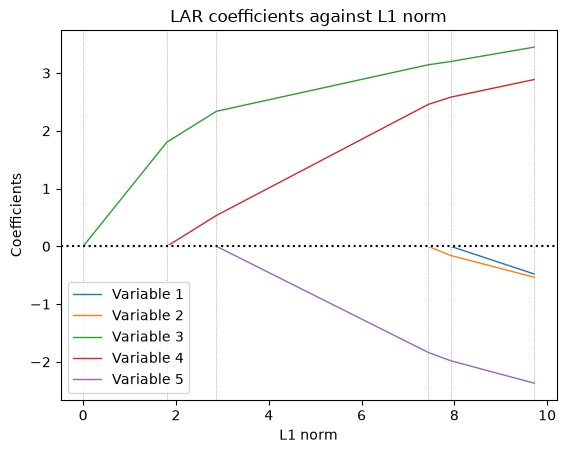

In [238]:
path = LAR_path(X, y)
beta_path = path['betas']
beta_L1 = [np.abs(int_beta).sum() for int_beta in beta_path]

import matplotlib.pyplot as plt

for i in range(5):
    plt.plot(beta_L1, [int_beta[i,0] for int_beta in beta_path], label=f'Variable {i+1}', lw=1)

for i in range(6):
    plt.axvline(x=beta_L1[i], c='grey', ls=':', lw=0.5)

plt.axhline(y=0, c='w')
plt.axhline(y=0, c='k', ls=':')
plt.title('LAR coefficients against L1 norm')
plt.xlabel('L1 norm')
plt.ylabel('Coefficients')
plt.legend(loc='lower left');

Since none of the variables' coefficients ever crossed $0$, the LAR path without the Lasso modification will already be the same as the Lasso path.

Now we plot the correlations of the variables with the current residual vector. As we can see, the maximum absolute correlation decreases throughout. Each time a non-active variable's absolute correlation reaches the current maximum, it gets absorbed into the active set and its correlation stays the largest amongst all variables.

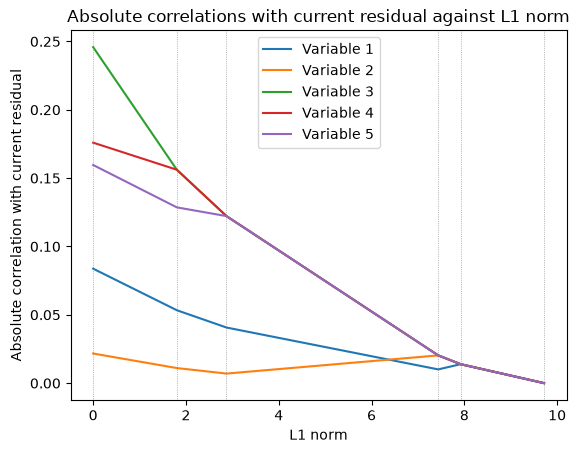

In [239]:
corrs = path['corrs']

for i in range(5):
    plt.plot(beta_L1, [corr[i] for corr in corrs], label=f'Variable {i+1}')

for i in range(6):
    plt.axvline(x=beta_L1[i], c='grey', ls=':', lw=0.5)

plt.title('Absolute correlations with current residual against L1 norm')
plt.xlabel('L1 norm')
plt.ylabel('Absolute correlation with current residual')
plt.legend();

## Choosing the Tuning Parameter

Ridge, lasso, and least angle regression all provide a path of coefficients from $0$ to the least squares solution. In order to make predictions, we need to pick a set of coefficients from the path provided by the regularisation technique used. Unfortunately, there is no foolproof theoretical way to choose the coefficients - we need to evaluate them by using a separate test data set.

In the code below, we plot the test residual sum of squares against log lambda (the tuning parameter in ridge regression), and choose the value of log lambda that gives the lowest RSS.

Least RSS = 201.51, attained at log lambda 2.26


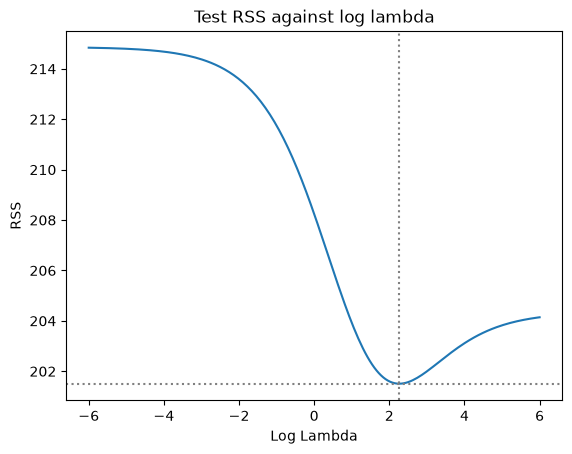

In [313]:
X_test = rng.random(size=(25,5))
y_test = X_test @ beta_true + beta_0_true + rng.normal(0, 3, size=25)

X_test_means = np.mean(X_test, axis=0)
X_test_centred = X_test - X_test_means

y_test_mean = np.mean(y_test)
y_test_centred = y_test - y_test_mean

X_predicted = [X_test_centred @ beta_hats[i,:] for i in range(beta_hats.shape[0])]
errors = [y_test_centred - X_pred for X_pred in X_predicted]
rss = [np.linalg.norm(error) ** 2 for error in errors]

index = np.argmin(rss)
min_rss = rss[index]
best_log_lambda = log_lambda[index]

plt.plot(log_lambda, rss)
plt.ylabel('RSS')
plt.xlabel('Log Lambda')
plt.title('Test RSS against log lambda')
plt.axvline(x=best_log_lambda, color='grey', ls=':')
plt.axhline(y=min_rss, color='grey', ls=':');

print(f'Least RSS = {min_rss:.2f}, attained at log lambda {best_log_lambda:.2f}')